# Lab 2 — Demo Formatore

### UF-16 · ML & AI · Modulo 1 · Hands-on Lab — Prima applicazione ML

> **Versione:** demo / instructor &nbsp;·&nbsp; **Durata:** ~90 min &nbsp;·&nbsp; **Ambiente:** Google Colab o Jupyter locale

Soluzioni complete di tutti i task del Lab 2: dal primo Hello World su scikit-learn al workflow end-to-end di classificazione sull'Iris dataset.

**Come usarlo in aula:**
- Mostralo solo dopo che i partecipanti hanno provato in autonomia.
- Le note segnalano i punti dove tipicamente si bloccano.
- Le note segnalano errori frequenti da prevenire.

---


## Esercizio 1 — Hello World su scikit-learn

> Apri questa sezione enfatizzando il messaggio chiave: **API uniforme**. Tutti gli algoritmi di scikit-learn hanno la stessa interfaccia `fit / predict / score`. Questo è il vero superpotere della libreria.


### Task 1.1 — Verifica installazione

In [1]:
import sklearn
print("scikit-learn version:", sklearn.__version__)

from sklearn import datasets, model_selection, neighbors, metrics
print("Moduli importati correttamente ")

scikit-learn version: 1.8.0


Moduli importati correttamente ✅


### Task 1.2 — Primo Estimator: tre algoritmi diversi, stessa API

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

knn = KNeighborsClassifier(n_neighbors=3)
logr = LogisticRegression(max_iter=1000)
tree = DecisionTreeClassifier(random_state=0)

print("k-NN params:")
print(knn.get_params())
print()
print("LogisticRegression params:")
print(logr.get_params())
print()
print("DecisionTree params:")
print(tree.get_params())
print()
print(f"Numero iperparametri: knn={len(knn.get_params())}, "
 f"logr={len(logr.get_params())}, tree={len(tree.get_params())}")

k-NN params:
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}

LogisticRegression params:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

DecisionTree params:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 0, 'splitter': 'best'}

Numero iperparametri:  knn=8,  logr=14,  tree=13


> Sottolinea: tutti e tre hanno `get_params()`. Tutti e tre avranno `.fit()`, `.predict()`, `.score()`. **Imparato uno, imparati tutti.**

### Task 1.3 — Dataset giocattolo: mela vs arancia

In [3]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

X_train = np.array([
 [150, 7], [170, 7.5], [140, 6.8], # mele
 [200, 8.5], [220, 9], [180, 8], # arance
])
y_train = np.array([0, 0, 0, 1, 1, 1])
nomi = np.array(["mela", "arancia"])

clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)

# Tre frutti di test
casi = np.array([
 [160, 7.2],
 [210, 8.7],
 [180, 7.5], # caso ambiguo
])

for misure in casi:
 pred = clf.predict([misure])[0]
 print(f"Peso={misure[0]:>4.0f}g, diam={misure[1]:.1f}cm → classe={pred} ({nomi[pred]})")

# Variazione di k
print()
print("Effetto di k sul frutto ambiguo [180, 7.5]:")
for k in [1, 3, 5]:
 m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
 pred = m.predict([[180, 7.5]])[0]
 print(f" k={k}: classe={pred} ({nomi[pred]})")

Peso= 160g, diam=7.2cm  →  classe=0 (mela)
Peso= 210g, diam=8.7cm  →  classe=1 (arancia)
Peso= 180g, diam=7.5cm  →  classe=1 (arancia)

Effetto di k sul frutto ambiguo [180, 7.5]:
  k=1: classe=1 (arancia)
  k=3: classe=1 (arancia)
  k=5: classe=0 (mela)


> Sul caso ambiguo `[180, 7.5]` la classificazione **può cambiare** con `k`. Apri una mini-discussione: "secondo voi è una mela grande o un'arancia piccola? E il modello, è d'accordo con voi?"

> Questo è il momento perfetto per anticipare l'idea che `k` è un **iperparametro che dovremo scegliere** — sarà il punto centrale del Task 2.7.

---
## Esercizio 2 — Classificazione Iris

> Apri con la storia: dataset del 1935 (Anderson) reso famoso da Fisher nel 1936. **Tre specie, quattro misure, 150 fiori.** Lo useremo perché è piccolo, pulito e si presta a un primo workflow ML completo in 10 minuti.


### Task 2.1 — Caricare ed esplorare il dataset

In [4]:
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()

print("Chiavi disponibili:", list(iris.keys()))
print()
print("Feature names :", iris.feature_names)
print("Target names :", iris.target_names)
print("Shape di data :", iris.data.shape)
print("Shape di target:", iris.target.shape)
print()

print("Prime 5 righe di data:")
print(iris.data[:5])
print()
print("Prime 10 etichette:")
print(iris.target[:10])
print()

unique, counts = np.unique(iris.target, return_counts=True)
print("Conteggio per classe:")
for u, c in zip(unique, counts):
 print(f" {u} ({iris.target_names[u]:10s}): {c} fiori")

Chiavi disponibili: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']

Feature names : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names  : ['setosa' 'versicolor' 'virginica']
Shape di data : (150, 4)
Shape di target: (150,)

Prime 5 righe di data:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Prime 10 etichette:
[0 0 0 0 0 0 0 0 0 0]

Conteggio per classe:
  0 (setosa    ): 50 fiori
  1 (versicolor): 50 fiori
  2 (virginica ): 50 fiori


> **Punto da sottolineare:** il dataset è **perfettamente bilanciato** (50 per classe). Questo è raro nei dati reali e rende l'accuracy una metrica affidabile. In dataset sbilanciati (es. frodi 1%) l'accuracy può ingannare e servono metriche diverse.

### Task 2.2 — Visualizzare i dati con un pair plot

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


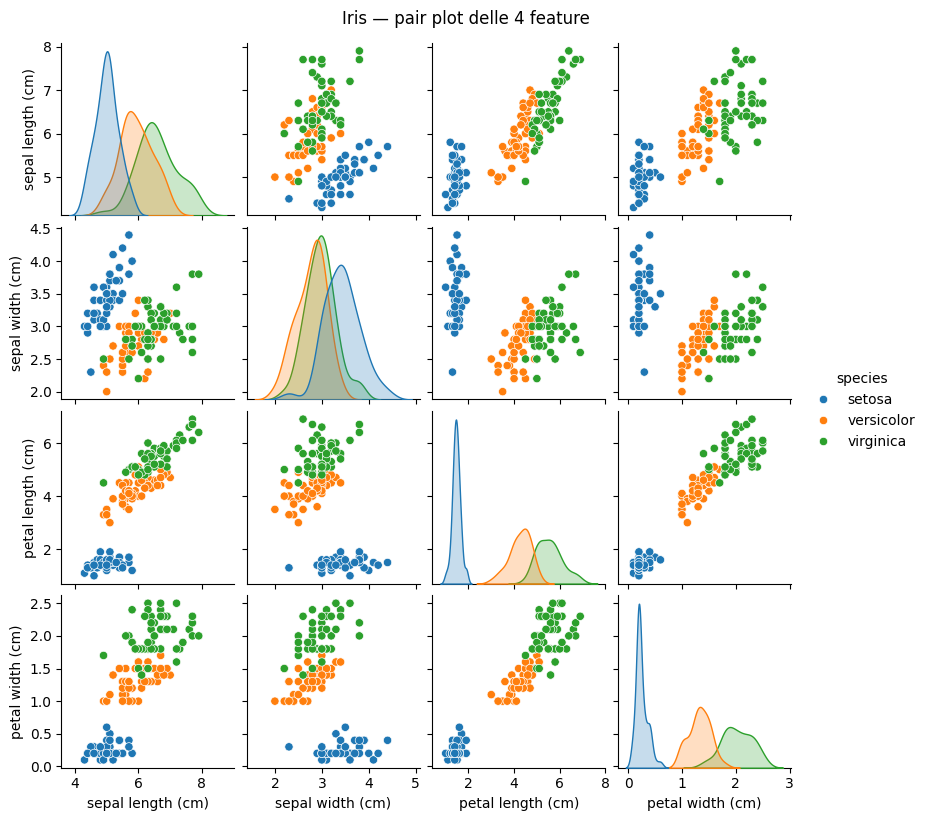

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = [iris.target_names[t] for t in iris.target]

print(df.head())
print()
print(df["species"].value_counts())

sns.pairplot(df, hue="species", height=2.0)
plt.suptitle("Iris — pair plot delle 4 feature", y=1.02)
plt.show()

**Scatter plot focalizzato su petalo (le due feature più discriminative):**

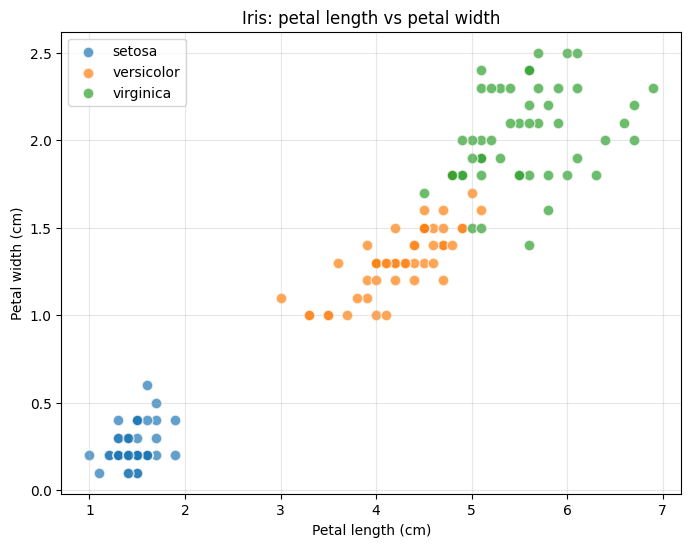

In [6]:
plt.figure(figsize=(8, 6))
for class_id, species_name in enumerate(iris.target_names):
 mask = iris.target == class_id
 plt.scatter(
 iris.data[mask, 2], # petal length
 iris.data[mask, 3], # petal width
 label=species_name, s=60, alpha=0.7, edgecolor="white",
 )
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris: petal length vs petal width")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

> **Domanda alla classe:** "Se doveste tracciare a mano la linea di separazione tra setosa e le altre, dove la mettereste?". Quasi tutti la disegnano correttamente. Questo *è* k-NN, nella sua intuizione di base.

> **Lezione chiave:** *setosa* è linearmente separabile. *Versicolor* e *virginica* si toccano. È esattamente lì che il modello sbaglierà.

### Task 2.3 — Train/test split

In [7]:
from sklearn.model_selection import train_test_split
import numpy as np

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
 X, y,
 test_size=0.25,
 random_state=0,
 stratify=y,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print()

# Verifica stratificazione
for name, target in [("train", y_train), ("test", y_test)]:
 unique, counts = np.unique(target, return_counts=True)
 print(f"Distribuzione classi nel {name}: ", end="")
 print({iris.target_names[u]: int(c) for u, c in zip(unique, counts)})

X_train shape: (112, 4)
X_test  shape: (38, 4)
y_train shape: (112,)
y_test  shape: (38,)

Distribuzione classi nel train: {np.str_('setosa'): 37, np.str_('versicolor'): 37, np.str_('virginica'): 38}
Distribuzione classi nel test: {np.str_('setosa'): 13, np.str_('versicolor'): 13, np.str_('virginica'): 12}


> Mostra cosa succede SENZA `stratify=y`: le proporzioni del test possono sbilanciarsi (es. 8 setosa, 15 versicolor, 15 virginica invece di 12-13-13). Mai grave su Iris, fatale su dataset sbilanciati. **Buona pratica universale: usare sempre `stratify=y` in classificazione.**

> Mostra anche cosa succede senza `random_state`: i numeri cambiano a ogni esecuzione → esperimenti non riproducibili → bug invisibili.

### Task 2.4 — Addestrare il classificatore k-NN

In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

print("Modello:", knn)
print("Vicini :", knn.n_neighbors)
print("Classi :", knn.classes_)
print()

# Score sul training: ingannevole!
print(f"Accuracy sul TRAINING (k=1): {knn.score(X_train, y_train):.4f}")
print(" È 1.0 perché ogni punto è il primo vicino di sé stesso.")
print(" Questo dato NON misura la generalizzazione.")
print()

# Confronto con k=5
knn5 = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
print(f"Accuracy sul TRAINING (k=5): {knn5.score(X_train, y_train):.4f}")
print(" Più realistico: il modello non memorizza più ogni singolo punto.")

Modello: KNeighborsClassifier(n_neighbors=1)
Vicini : 1
Classi : [0 1 2]

Accuracy sul TRAINING (k=1): 1.0000
  ⚠️  È 1.0 perché ogni punto è il primo vicino di sé stesso.
  ⚠️  Questo dato NON misura la generalizzazione.

Accuracy sul TRAINING (k=5): 0.9554
  Più realistico: il modello non memorizza più ogni singolo punto.


> **Discussione da innescare:** "Perché lo score di training a k=1 è 1.0?". Lascia che ci arrivino: il primo vicino di ogni punto è sé stesso (distanza 0), quindi la classe predetta è sempre quella corretta. **Da qui parte tutto il discorso sull'overfitting.**

### Task 2.5 — Predire su nuovi fiori

In [9]:
import numpy as np

# Tre fiori di test
nuovi_fiori = np.array([
 [5.1, 3.5, 1.4, 0.2],
 [6.7, 3.0, 5.2, 2.3],
 [5.7, 2.8, 4.1, 1.3],
])

predictions = knn.predict(nuovi_fiori)
probas = knn.predict_proba(nuovi_fiori)

for i, fiore in enumerate(nuovi_fiori):
 cls = predictions[i]
 name = iris.target_names[cls]
 prob = probas[i]
 print(f"Fiore {i+1}: {fiore}")
 print(f" → predizione: {cls} ({name})")
 print(f" → probabilità: {dict(zip(iris.target_names, prob))}")
 print()

Fiore 1: [5.1 3.5 1.4 0.2]
  → predizione: 0 (setosa)
  → probabilità: {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(0.0)}

Fiore 2: [6.7 3.  5.2 2.3]
  → predizione: 2 (virginica)
  → probabilità: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(1.0)}

Fiore 3: [5.7 2.8 4.1 1.3]
  → predizione: 1 (versicolor)
  → probabilità: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(1.0), np.str_('virginica'): np.float64(0.0)}



**Errore tipico — array 1D invece di 2D:**

In [10]:
try:
 knn.predict([5.0, 2.9, 1.0, 0.2]) # array 1D
except Exception as e:
 print(f" Errore: {type(e).__name__}")
 print(f" Messaggio: {str(e)[:200]}...")
 print()
 print(" Soluzione: usa SEMPRE shape (n_samples, n_features).")
 print(" Per un solo fiore: doppie parentesi → [[5.0, 2.9, 1.0, 0.2]]")
 print()
 # Versione corretta
 pred = knn.predict([[5.0, 2.9, 1.0, 0.2]])
 print(f" Predizione corretta: {pred} ({iris.target_names[pred[0]]})")

❌ Errore: ValueError
   Messaggio: Expected 2D array, got 1D array instead:
array=[5.  2.9 1.  0.2].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single ...

✅ Soluzione: usa SEMPRE shape (n_samples, n_features).
   Per un solo fiore: doppie parentesi → [[5.0, 2.9, 1.0, 0.2]]

   Predizione corretta: [0] (setosa)


> Quasi tutti i partecipanti incontrano questo errore almeno una volta. Mostralo deliberatamente: imparare a **leggere il messaggio di errore** è una competenza chiave.

### Task 2.6 — Valutare il modello sul test set

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

y_pred = knn.predict(X_test)

# Tre modi equivalenti di calcolare l'accuracy
print("Accuracy (manuale) :", np.mean(y_pred == y_test))
print("Accuracy (sklearn) :", accuracy_score(y_test, y_pred))
print("Accuracy (.score()) :", knn.score(X_test, y_test))
print()

# Confusion matrix
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print()

# Classification report
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy (manuale)  : 0.9736842105263158
Accuracy (sklearn)  : 0.9736842105263158
Accuracy (.score()) : 0.9736842105263158

Confusion matrix:
[[13  0  0]
 [ 0 13  0]
 [ 0  1 11]]

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



**Confusion matrix visualizzata:**

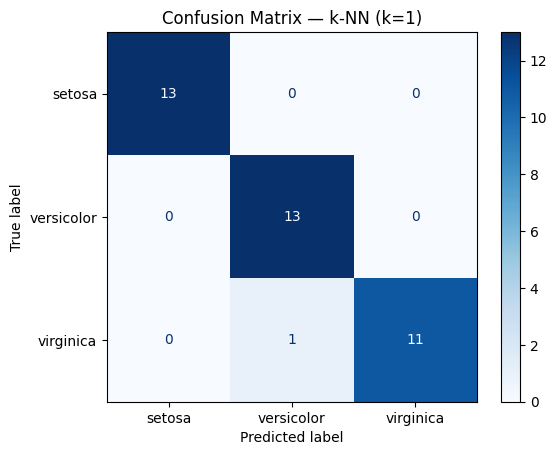

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_estimator(
 knn, X_test, y_test,
 display_labels=iris.target_names,
 cmap="Blues",
)
plt.title("Confusion Matrix — k-NN (k=1)")
plt.grid(False)
plt.show()

> **Discussione:**
> - Una **setosa** sbagliata sarebbe sorprendente: nel pair plot era isolata. Non succede mai.
> - Gli errori tipicamente sono tra **versicolor e virginica**, le due specie che si toccano. **Coerente con quello che il pair plot mostrava.**
> - Questo è un punto pedagogico forte: la qualità del modello dipende dalla **separabilità delle classi nello spazio delle feature**, non dalla scelta dell'algoritmo.

> **Glossario rapido del classification report:**
> - **precision** = sui fiori che ho predetto come X, quanti erano davvero X?
> - **recall** = sui fiori veramente X, quanti ne ho identificati?
> - **f1-score** = media armonica di precision e recall.
> - **support** = quanti fiori di quella classe ci sono nel test.

### Task 2.7 — Sperimentare con il parametro k

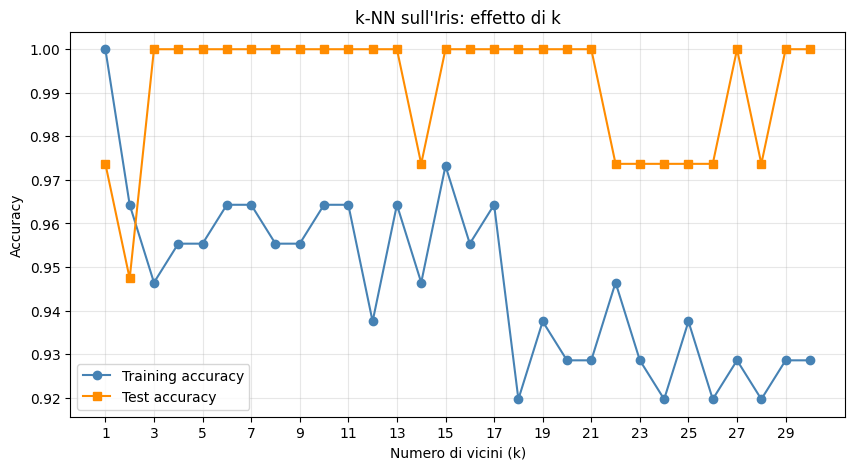

Miglior k sul test: 3
Accuracy a quel k:  1.0000

Accuracy training a k=1 : 1.0000
Accuracy training a k=30: 0.9286


In [13]:
import matplotlib.pyplot as plt
import numpy as np

k_values = list(range(1, 31))
train_scores = []
test_scores = []

for k in k_values:
 model = KNeighborsClassifier(n_neighbors=k)
 model.fit(X_train, y_train)
 train_scores.append(model.score(X_train, y_train))
 test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_scores, "o-", label="Training accuracy", color="steelblue")
plt.plot(k_values, test_scores, "s-", label="Test accuracy", color="darkorange")
plt.xlabel("Numero di vicini (k)")
plt.ylabel("Accuracy")
plt.title("k-NN sull'Iris: effetto di k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values[::2])
plt.show()

best_k_test = k_values[int(np.argmax(test_scores))]
print(f"Miglior k sul test: {best_k_test}")
print(f"Accuracy a quel k: {max(test_scores):.4f}")
print()
print(f"Accuracy training a k=1 : {train_scores[0]:.4f}")
print(f"Accuracy training a k=30: {train_scores[-1]:.4f}")

> **Tre messaggi chiave da consolidare alla fine del lab:**
>
> 1. **Overfitting (k=1):** training perfetto, test buono ma fragile. Il modello "ricorda" i punti vicini.
> 2. **Underfitting (k molto alto):** training peggiora, test peggiora. Il modello fa una media su troppi vicini.
> 3. **Scegliere k sul test set è BARARE.** Il modo corretto è la **cross-validation** sul training. Lo vedremo nei prossimi moduli.

> **Onestà intellettuale:** anche se troviamo "il miglior k sul test" qui, questo numero è già "contaminato". In un progetto reale, dopo aver scelto k via cross-validation sul training, useresti il test set **una sola volta** per la valutazione finale.

---
## Chiusura del lab

Abbiamo coperto in ~90 minuti il **workflow ML supervised end-to-end**:

| Step | Cosa abbiamo fatto |
|-----------------------------|------------------------------------------------------|
| 1. **Load** | `load_iris()` → matrice 150×4, etichette 0/1/2 |
| 2. **Explore** | pair plot → classi separate sui petali |
| 3. **Split** | 75/25 con `stratify=y` e `random_state=0` |
| 4. **Train** | `KNeighborsClassifier(n_neighbors=1).fit(X, y)` |
| 5. **Predict** | `.predict(X_new)` con input 2D |
| 6. **Evaluate** | accuracy + confusion matrix + classification report |
| 7. **Tune hyperparams** | Loop su `k`, grafico training/test |

### Cosa abbiamo NON ancora fatto (e che vedremo nei moduli successivi)

- **Feature scaling**: k-NN è sensibile alla scala delle feature.
- **Cross-validation**: per scegliere `k` in modo onesto senza toccare il test set.
- **GridSearchCV**: automatizzare la ricerca degli iperparametri.
- **Pipeline**: combinare preprocessing + modello in un solo oggetto.
- **Altri algoritmi**: regressione logistica, SVM, alberi, ensemble.

### Domande aperte da fare alla classe

> - "Se domani vi danno un dataset nuovo con 100k righe e 200 feature, fareste partire da k-NN?"
> - "Quanto del lavoro che abbiamo fatto era 'machine learning' e quanto era esplorazione dati?"
> - "Sul vostro dominio, cosa sarebbe più impattante: un modello più potente o feature meglio costruite?"

 **Prossimo modulo:** dataset più realistici, preprocessing, e altri algoritmi di classificazione.
